Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): -3.324514043677754
Max ΔP (%): 87.74708564593648


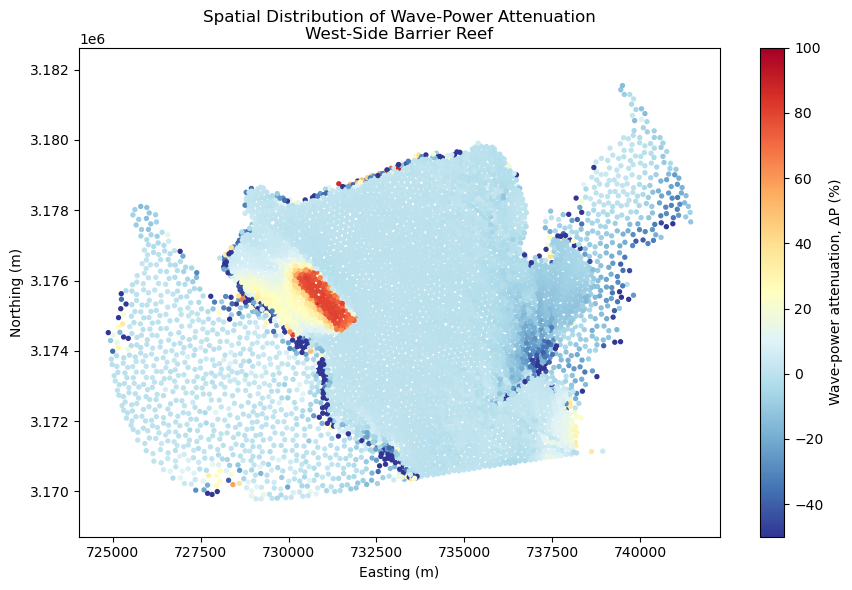

In [2]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"

# Optional target time for single-time spatial map
target_time = np.datetime64("2017-08-26T02:30:00")

# =========================
# Open files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# Use no-reef mesh as reference grid
geom_ref = p_no_reef_all.geometry
xy_ref = geom_ref.element_coordinates[:, :2]

# Interpolant: reef result -> no-reef mesh
elem_ids, weights = p_reef_all.geometry.get_2d_interpolant(
    xy_ref,
    n_nearest=3,
    extrapolate=False
)

# =========================
# Function: interpolate reef P to no-reef grid
# =========================
def interp_reef_to_ref(da_reef_t):
    return da_reef_t.geometry.interp2d(
        da_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# 1. Spatial ΔP map at target time
# =========================
time_index = np.argmin(np.abs(ds_no_reef.time.values - target_time))
selected_time = ds_no_reef.time.values[time_index]

p_no = p_no_reef_all.isel(time=time_index).to_numpy().flatten()
p_rf = interp_reef_to_ref(p_reef_all.isel(time=time_index))

# Avoid division by zero
p_no_safe = np.where(p_no > 1e-6, p_no, np.nan)

# Percentage wave-power attenuation
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))

# Plot spatial ΔP
plt.figure(figsize=(9, 6))
sc = plt.scatter(
    xy_ref[:, 0],
    xy_ref[:, 1],
    c=delta_p,
    s=8,
    cmap="RdYlBu_r",
    vmin=-50,
    vmax=100
)

plt.colorbar(sc, label="Wave-power attenuation, ΔP (%)")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.title("Spatial Distribution of Wave-Power Attenuation\nWest-Side Barrier Reef")
plt.axis("equal")
plt.tight_layout()
plt.show()


Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): -3.324514043677754
Max ΔP (%): 87.74708564593648
Min ΔP (%): -2912.034496973584


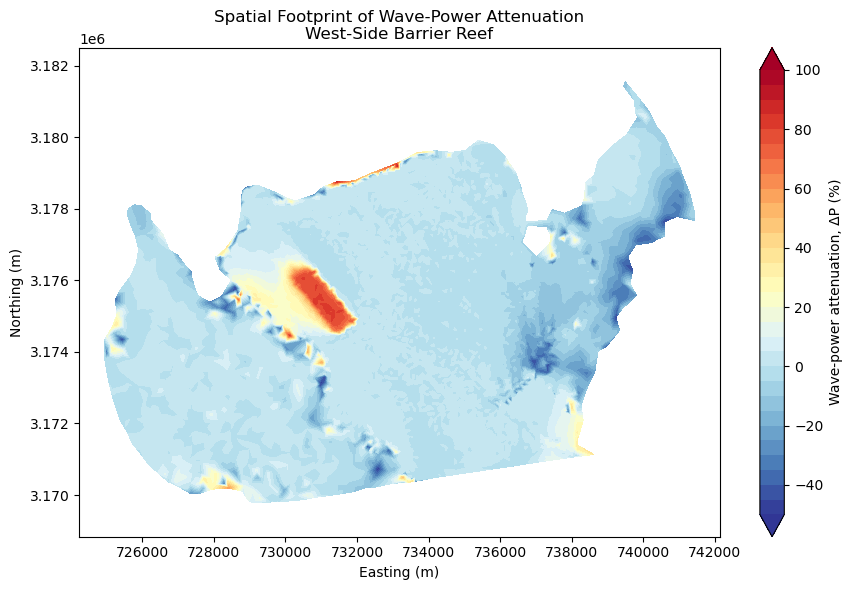

In [4]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"

target_time = np.datetime64("2017-08-26T02:30:00")

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# Reference grid: no-reef mesh
geom_ref = p_no_reef_all.geometry
xy_ref = geom_ref.element_coordinates[:, :2]

# Interpolate reef result to no-reef mesh
elem_ids, weights = p_reef_all.geometry.get_2d_interpolant(
    xy_ref,
    n_nearest=3,
    extrapolate=False
)

def interp_reef_to_ref(da_reef_t):
    return da_reef_t.geometry.interp2d(
        da_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP at target time
# =========================
time_index = np.argmin(np.abs(ds_no_reef.time.values - target_time))
selected_time = ds_no_reef.time.values[time_index]

p_no = p_no_reef_all.isel(time=time_index).to_numpy().flatten()
p_rf = interp_reef_to_ref(p_reef_all.isel(time=time_index))

# Avoid division by zero
p_no_safe = np.where(p_no > 1e-6, p_no, np.nan)

# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Smooth spatial footprint plot
# =========================
x = xy_ref[:, 0]
y = xy_ref[:, 1]
z = delta_p.copy()

# Mask invalid values
valid = np.isfinite(z)

# Optional: remove extreme/noisy values
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

# Create triangulation
triang = tri.Triangulation(x_valid, y_valid)

# Mask large triangles to avoid interpolation over land/gaps
triangles = triang.triangles

xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])

# Adjust this threshold if needed
# Smaller value = less interpolation across land/gaps
triang.set_mask(max_edge > 600)

# Plot smooth filled spatial footprint only
plt.figure(figsize=(9, 6))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

cbar = plt.colorbar(cf)
cbar.set_label("Wave-power attenuation, ΔP (%)")

plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.title("Spatial Footprint of Wave-Power Attenuation\nWest-Side Barrier Reef")

plt.axis("equal")
plt.tight_layout()
plt.show()

Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): -4.8184642590841
Max ΔP (%): 92.89760255735662
Min ΔP (%): -2942.344967656618


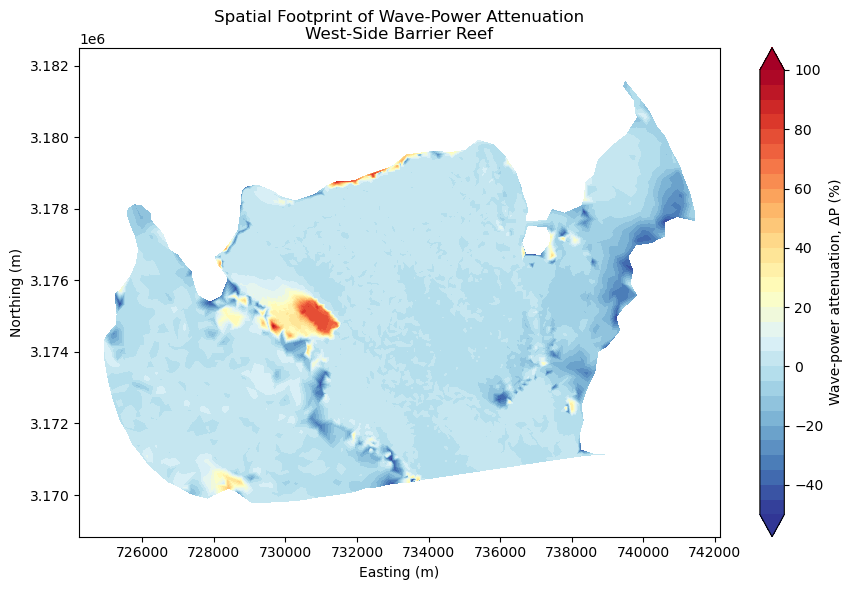

In [12]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_v1.sw - Result Files\west_side_barrier_reef_v1.dfsu"

dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"

target_time = np.datetime64("2017-08-26T02:30:00")

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# Reference grid: no-reef mesh
geom_ref = p_no_reef_all.geometry
xy_ref = geom_ref.element_coordinates[:, :2]

# Interpolate reef result to no-reef mesh
elem_ids, weights = p_reef_all.geometry.get_2d_interpolant(
    xy_ref,
    n_nearest=3,
    extrapolate=False
)

def interp_reef_to_ref(da_reef_t):
    return da_reef_t.geometry.interp2d(
        da_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP at target time
# =========================
time_index = np.argmin(np.abs(ds_no_reef.time.values - target_time))
selected_time = ds_no_reef.time.values[time_index]

p_no = p_no_reef_all.isel(time=time_index).to_numpy().flatten()
p_rf = interp_reef_to_ref(p_reef_all.isel(time=time_index))

# Avoid division by zero
p_no_safe = np.where(p_no > 1e-6, p_no, np.nan)

# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Smooth spatial footprint plot
# =========================
x = xy_ref[:, 0]
y = xy_ref[:, 1]
z = delta_p.copy()

# Mask invalid values
valid = np.isfinite(z)

# Optional: remove extreme/noisy values
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

# Create triangulation
triang = tri.Triangulation(x_valid, y_valid)

# Mask large triangles to avoid interpolation over land/gaps
triangles = triang.triangles

xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])

# Adjust this threshold if needed
# Smaller value = less interpolation across land/gaps
triang.set_mask(max_edge > 600)

# Plot smooth filled spatial footprint only
plt.figure(figsize=(9, 6))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

cbar = plt.colorbar(cf)
cbar.set_label("Wave-power attenuation, ΔP (%)")

plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.title("Spatial Footprint of Wave-Power Attenuation\nWest-Side Barrier Reef")

plt.axis("equal")
plt.tight_layout()
plt.show()

Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): -5.789190720887949
Max ΔP (%): 93.01638411204077
Min ΔP (%): -2918.807940816834


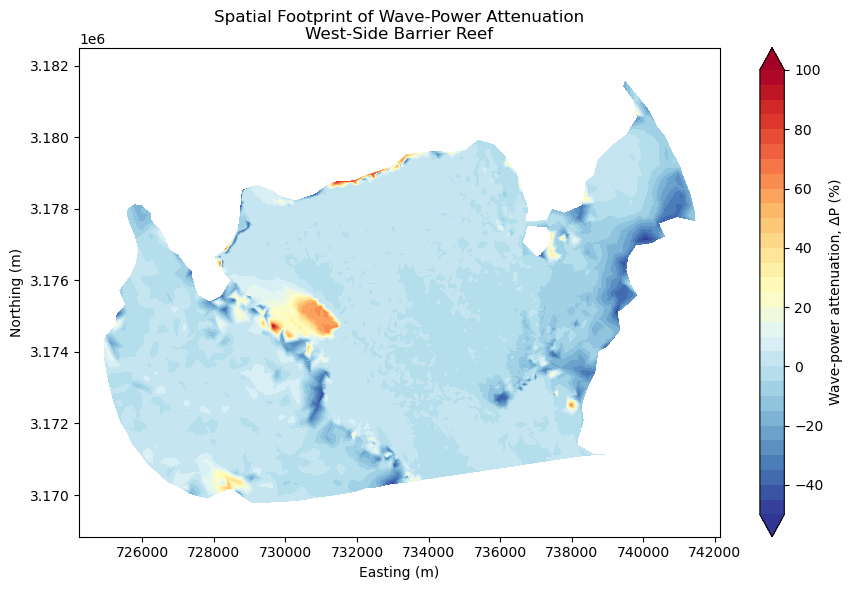

In [16]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_v2.sw - Result Files\west_side_barrier_reef_1.5m_v2.dfsu"

dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"

target_time = np.datetime64("2017-08-26T02:30:00")

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# Reference grid: no-reef mesh
geom_ref = p_no_reef_all.geometry
xy_ref = geom_ref.element_coordinates[:, :2]

# Interpolate reef result to no-reef mesh
elem_ids, weights = p_reef_all.geometry.get_2d_interpolant(
    xy_ref,
    n_nearest=3,
    extrapolate=False
)

def interp_reef_to_ref(da_reef_t):
    return da_reef_t.geometry.interp2d(
        da_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP at target time
# =========================
time_index = np.argmin(np.abs(ds_no_reef.time.values - target_time))
selected_time = ds_no_reef.time.values[time_index]

p_no = p_no_reef_all.isel(time=time_index).to_numpy().flatten()
p_rf = interp_reef_to_ref(p_reef_all.isel(time=time_index))

# Avoid division by zero
p_no_safe = np.where(p_no > 1e-6, p_no, np.nan)

# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Smooth spatial footprint plot
# =========================
x = xy_ref[:, 0]
y = xy_ref[:, 1]
z = delta_p.copy()

# Mask invalid values
valid = np.isfinite(z)

# Optional: remove extreme/noisy values
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

# Create triangulation
triang = tri.Triangulation(x_valid, y_valid)

# Mask large triangles to avoid interpolation over land/gaps
triangles = triang.triangles

xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])

# Adjust this threshold if needed
# Smaller value = less interpolation across land/gaps
triang.set_mask(max_edge > 600)

# Plot smooth filled spatial footprint only
plt.figure(figsize=(9, 6))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

cbar = plt.colorbar(cf)
cbar.set_label("Wave-power attenuation, ΔP (%)")

plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.title("Spatial Footprint of Wave-Power Attenuation\nWest-Side Barrier Reef")

plt.axis("equal")
plt.tight_layout()
plt.show()

Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): -5.789190720887949
Max ΔP (%): 93.01638411204077
Min ΔP (%): -2918.807940816834


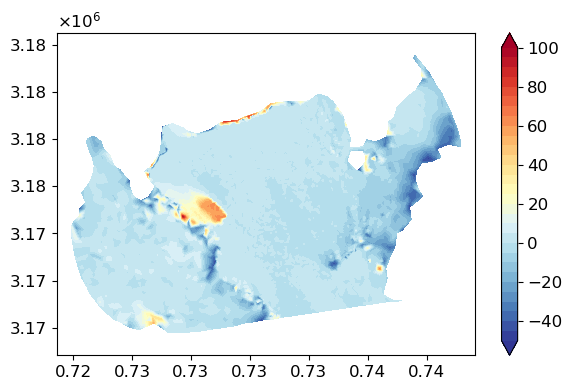

In [9]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.ticker import FormatStrFormatter

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_v2.sw - Result Files\west_side_barrier_reef_1.5m_v2.dfsu"
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"

target_time = np.datetime64("2017-08-26T02:30:00")

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# Reference grid: no-reef mesh
geom_ref = p_no_reef_all.geometry
xy_ref = geom_ref.element_coordinates[:, :2]

# Interpolate reef result to no-reef mesh
elem_ids, weights = p_reef_all.geometry.get_2d_interpolant(
    xy_ref,
    n_nearest=3,
    extrapolate=False
)

def interp_reef_to_ref(da_reef_t):
    return da_reef_t.geometry.interp2d(
        da_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP at target time
# =========================
time_index = np.argmin(np.abs(ds_no_reef.time.values - target_time))
selected_time = ds_no_reef.time.values[time_index]

p_no = p_no_reef_all.isel(time=time_index).to_numpy().flatten()
p_rf = interp_reef_to_ref(p_reef_all.isel(time=time_index))

# Avoid division by zero
p_no_safe = np.where(p_no > 1e-6, p_no, np.nan)

# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Smooth spatial footprint plot
# =========================
x = xy_ref[:, 0]
y = xy_ref[:, 1]
z = delta_p.copy()

# Mask invalid values
valid = np.isfinite(z)

# Optional: remove extreme/noisy values
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

# Create triangulation
triang = tri.Triangulation(x_valid, y_valid)

# Mask large triangles to avoid interpolation over land/gaps
triangles = triang.triangles

xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])

# Adjust this threshold if needed
triang.set_mask(max_edge > 600)

# =========================
# Plot
# =========================

from matplotlib.ticker import FuncFormatter

tick_size = 12

plt.figure(figsize=(6, 4))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

# -------------------------
# Colorbar
# -------------------------
cbar = plt.colorbar(cf)
cbar.ax.tick_params(labelsize=tick_size)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
cbar.update_ticks()

# -------------------------
# Axes formatting
# -------------------------
ax = plt.gca()

# Tick label size
ax.tick_params(axis='both', labelsize=tick_size)

# Scientific notation with 2 decimals
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.2f}'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y/1e6:.2f}'))

# Display scientific multiplier (×10^6)
ax.text(
    0.0, 1.01,
    r'$\times10^{6}$',
    transform=ax.transAxes,
    fontsize=tick_size,
    ha='left',
    va='bottom'
)

# plt.xlabel("Easting (m)")
# plt.ylabel("Northing (m)")
# plt.title("Spatial Footprint of Wave-Power Attenuation\nEast-Side Barrier Reef")

plt.axis("equal")
plt.tight_layout()
plt.show()

Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): -67.70256071694577
Max ΔP (%): 96.27098936518507
Min ΔP (%): -491417.43168567366


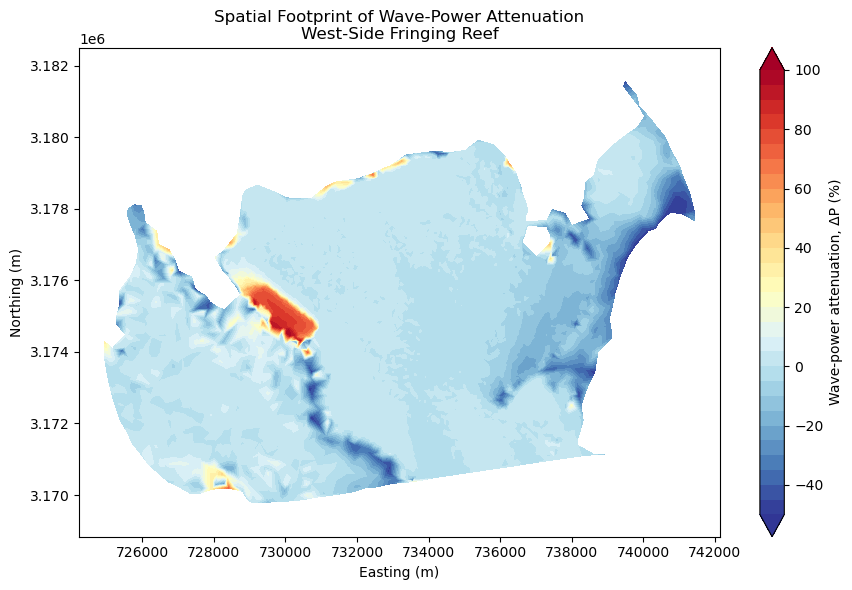

In [5]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_fringing_reef.sw - Result Files\west_side_fringing_reef.dfsu"

dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"

target_time = np.datetime64("2017-08-26T02:30:00")

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# Reference grid: no-reef mesh
geom_ref = p_no_reef_all.geometry
xy_ref = geom_ref.element_coordinates[:, :2]

# Interpolate reef result to no-reef mesh
elem_ids, weights = p_reef_all.geometry.get_2d_interpolant(
    xy_ref,
    n_nearest=3,
    extrapolate=False
)

def interp_reef_to_ref(da_reef_t):
    return da_reef_t.geometry.interp2d(
        da_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP at target time
# =========================
time_index = np.argmin(np.abs(ds_no_reef.time.values - target_time))
selected_time = ds_no_reef.time.values[time_index]

p_no = p_no_reef_all.isel(time=time_index).to_numpy().flatten()
p_rf = interp_reef_to_ref(p_reef_all.isel(time=time_index))

# Avoid division by zero
p_no_safe = np.where(p_no > 1e-6, p_no, np.nan)

# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Smooth spatial footprint plot
# =========================
x = xy_ref[:, 0]
y = xy_ref[:, 1]
z = delta_p.copy()

# Mask invalid values
valid = np.isfinite(z)

# Optional: remove extreme/noisy values
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

# Create triangulation
triang = tri.Triangulation(x_valid, y_valid)

# Mask large triangles to avoid interpolation over land/gaps
triangles = triang.triangles

xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])

# Adjust this threshold if needed
# Smaller value = less interpolation across land/gaps
triang.set_mask(max_edge > 600)

# Plot smooth filled spatial footprint only
plt.figure(figsize=(9, 6))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

cbar = plt.colorbar(cf)
cbar.set_label("Wave-power attenuation, ΔP (%)")

plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.title("Spatial Footprint of Wave-Power Attenuation\nWest-Side Fringing Reef")

plt.axis("equal")
plt.tight_layout()
plt.show()

Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): -9.956295787937014
Max ΔP (%): 95.82738862615376
Min ΔP (%): -11863.646916844262


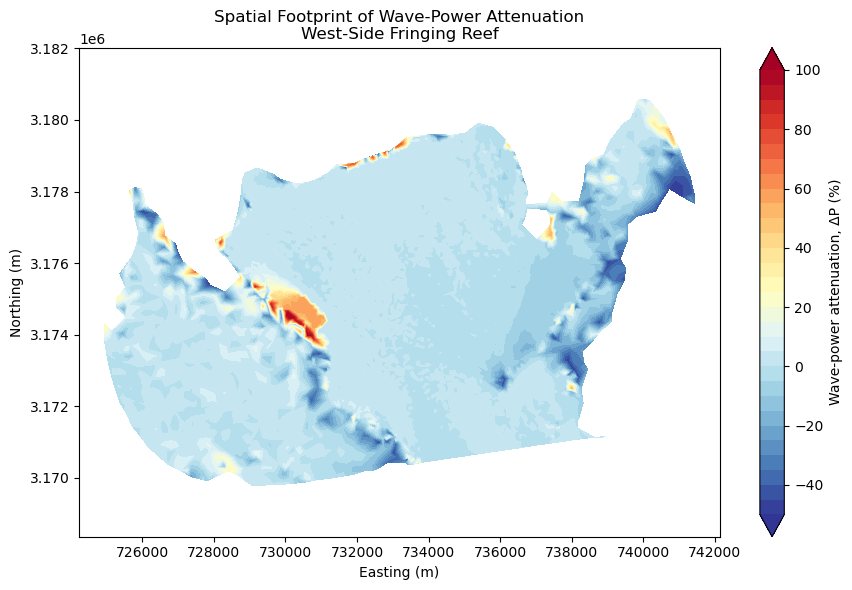

In [1]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_fringing_reef_v1.sw - Result Files\west_side_fringing_reef_1.5m_v2.dfsu"

dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"

target_time = np.datetime64("2017-08-26T02:30:00")

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# Reference grid: no-reef mesh
geom_ref = p_no_reef_all.geometry
xy_ref = geom_ref.element_coordinates[:, :2]

# Interpolate reef result to no-reef mesh
elem_ids, weights = p_reef_all.geometry.get_2d_interpolant(
    xy_ref,
    n_nearest=3,
    extrapolate=False
)

def interp_reef_to_ref(da_reef_t):
    return da_reef_t.geometry.interp2d(
        da_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP at target time
# =========================
time_index = np.argmin(np.abs(ds_no_reef.time.values - target_time))
selected_time = ds_no_reef.time.values[time_index]

p_no = p_no_reef_all.isel(time=time_index).to_numpy().flatten()
p_rf = interp_reef_to_ref(p_reef_all.isel(time=time_index))

# Avoid division by zero
p_no_safe = np.where(p_no > 1e-6, p_no, np.nan)

# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Smooth spatial footprint plot
# =========================
x = xy_ref[:, 0]
y = xy_ref[:, 1]
z = delta_p.copy()

# Mask invalid values
valid = np.isfinite(z)

# Optional: remove extreme/noisy values
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

# Create triangulation
triang = tri.Triangulation(x_valid, y_valid)

# Mask large triangles to avoid interpolation over land/gaps
triangles = triang.triangles

xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])

# Adjust this threshold if needed
# Smaller value = less interpolation across land/gaps
triang.set_mask(max_edge > 600)

# Plot smooth filled spatial footprint only
plt.figure(figsize=(9, 6))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

cbar = plt.colorbar(cf)
cbar.set_label("Wave-power attenuation, ΔP (%)")

plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.title("Spatial Footprint of Wave-Power Attenuation\nWest-Side Fringing Reef")

plt.axis("equal")
plt.tight_layout()
plt.show()

Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): -9.956295787937014
Max ΔP (%): 95.82738862615376
Min ΔP (%): -11863.646916844262


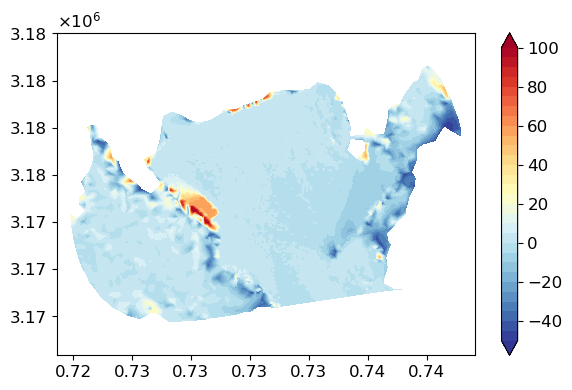

In [8]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.ticker import FormatStrFormatter

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_fringing_reef_v1.sw - Result Files\west_side_fringing_reef_1.5m_v2.dfsu"
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"

target_time = np.datetime64("2017-08-26T02:30:00")

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# Reference grid: no-reef mesh
geom_ref = p_no_reef_all.geometry
xy_ref = geom_ref.element_coordinates[:, :2]

# Interpolate reef result to no-reef mesh
elem_ids, weights = p_reef_all.geometry.get_2d_interpolant(
    xy_ref,
    n_nearest=3,
    extrapolate=False
)

def interp_reef_to_ref(da_reef_t):
    return da_reef_t.geometry.interp2d(
        da_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP at target time
# =========================
time_index = np.argmin(np.abs(ds_no_reef.time.values - target_time))
selected_time = ds_no_reef.time.values[time_index]

p_no = p_no_reef_all.isel(time=time_index).to_numpy().flatten()
p_rf = interp_reef_to_ref(p_reef_all.isel(time=time_index))

# Avoid division by zero
p_no_safe = np.where(p_no > 1e-6, p_no, np.nan)

# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Smooth spatial footprint plot
# =========================
x = xy_ref[:, 0]
y = xy_ref[:, 1]
z = delta_p.copy()

# Mask invalid values
valid = np.isfinite(z)

# Optional: remove extreme/noisy values
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

# Create triangulation
triang = tri.Triangulation(x_valid, y_valid)

# Mask large triangles to avoid interpolation over land/gaps
triangles = triang.triangles

xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])

# Adjust this threshold if needed
triang.set_mask(max_edge > 600)

# =========================
# Plot
# =========================

from matplotlib.ticker import FuncFormatter

tick_size = 12

plt.figure(figsize=(6, 4))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

# -------------------------
# Colorbar
# -------------------------
cbar = plt.colorbar(cf)
cbar.ax.tick_params(labelsize=tick_size)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
cbar.update_ticks()

# -------------------------
# Axes formatting
# -------------------------
ax = plt.gca()

# Tick label size
ax.tick_params(axis='both', labelsize=tick_size)

# Scientific notation with 2 decimals
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.2f}'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y/1e6:.2f}'))

# Display scientific multiplier (×10^6)
ax.text(
    0.0, 1.01,
    r'$\times10^{6}$',
    transform=ax.transAxes,
    fontsize=tick_size,
    ha='left',
    va='bottom'
)

# plt.xlabel("Easting (m)")
# plt.ylabel("Northing (m)")
# plt.title("Spatial Footprint of Wave-Power Attenuation\nEast-Side Barrier Reef")

plt.axis("equal")
plt.tight_layout()
plt.show()

Selected timestep no reef: 2017-08-26T02:30:00.000000000
Selected timestep barrier reef: 2017-08-26T02:30:00.000000000
Selected timestep fringing reef: 2017-08-26T02:30:00.000000000
Barrier reef mean ΔP (%): 42.854501263611944
Barrier reef max ΔP (%): 81.08218183618445
Fringing reef mean ΔP (%): 30.646196712761956
Fringing reef max ΔP (%): 86.7302599428775


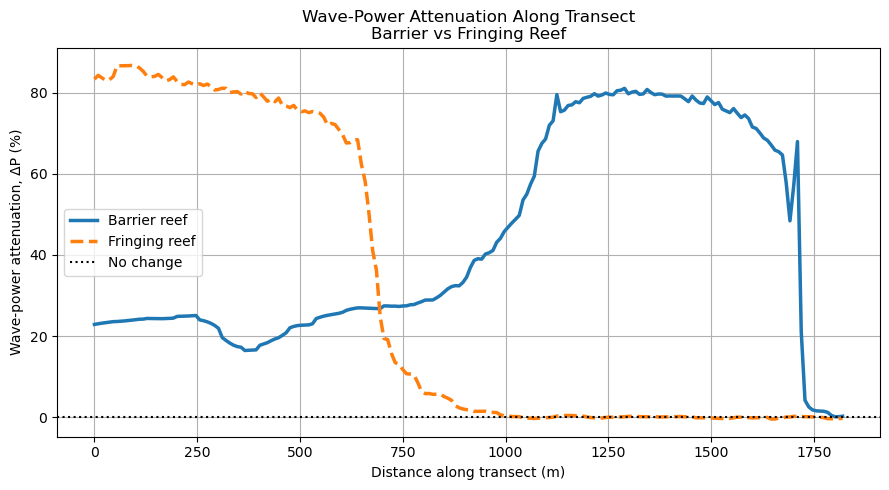

In [6]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# Barrier reef condition
dfsu_barrier = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

# Fringing reef condition
dfsu_fringing = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_fringing_reef.sw - Result Files\west_side_fringing_reef.dfsu"

# No reef baseline
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"

# =========================
# Transect endpoints
# =========================
x1, y1 = 729827, 3174795
x2, y2 = 731393, 3175721

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Target time
# =========================
target_time = np.datetime64("2017-08-26T02:30:00")


# =========================
# Function to extract profile
# =========================
def extract_profile(dfsu_file, item_name, coords, target_time):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time


# =========================
# Extract wave power profiles
# =========================

p_no_reef, time_no = extract_profile(
    dfsu_no_reef,
    item_name,
    coords,
    target_time
)

p_barrier, time_barrier = extract_profile(
    dfsu_barrier,
    item_name,
    coords,
    target_time
)

p_fringing, time_fringing = extract_profile(
    dfsu_fringing,
    item_name,
    coords,
    target_time
)

print("Selected timestep no reef:", time_no)
print("Selected timestep barrier reef:", time_barrier)
print("Selected timestep fringing reef:", time_fringing)

# =========================
# Calculate ΔP profiles
# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
# =========================

p_no_safe = np.where(p_no_reef > 1e-6, p_no_reef, np.nan)

delta_p_barrier = ((p_no_safe - p_barrier) / p_no_safe) * 100
delta_p_fringing = ((p_no_safe - p_fringing) / p_no_safe) * 100

print("Barrier reef mean ΔP (%):", np.nanmean(delta_p_barrier))
print("Barrier reef max ΔP (%):", np.nanmax(delta_p_barrier))
print("Fringing reef mean ΔP (%):", np.nanmean(delta_p_fringing))
print("Fringing reef max ΔP (%):", np.nanmax(delta_p_fringing))

# =========================
# Plot ΔP profiles
# =========================

plt.figure(figsize=(9, 5))

plt.plot(
    distance,
    delta_p_barrier,
    linewidth=2.5,
    label="Barrier reef"
)

plt.plot(
    distance,
    delta_p_fringing,
    linewidth=2.5,
    linestyle="--",
    label="Fringing reef"
)

plt.axhline(
    y=0,
    color="k",
    linestyle=":",
    linewidth=1.5,
    label="No change"
)

plt.xlabel("Distance along transect (m)")
plt.ylabel("Wave-power attenuation, ΔP (%)")
plt.title("Wave-Power Attenuation Along Transect\nBarrier vs Fringing Reef")
plt.grid(True)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

Selected timestep no reef: 2017-08-26T02:30:00.000000000
Selected timestep barrier reef: 2017-08-26T02:30:00.000000000
Selected timestep fringing reef: 2017-08-26T02:30:00.000000000
Barrier reef mean ΔP (%): 28.379699225739163
Barrier reef max ΔP (%): 64.10399165727566
Fringing reef mean ΔP (%): 18.532516795098694
Fringing reef max ΔP (%): 59.06353351747882


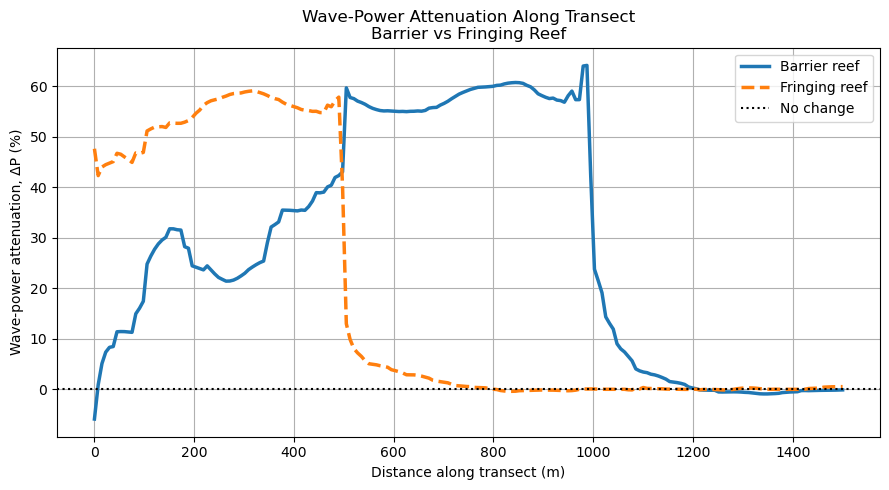

In [2]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# Barrier reef condition
dfsu_barrier = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_v2.sw - Result Files\west_side_barrier_reef_1.5m_v2.dfsu"

# Fringing reef condition
dfsu_fringing = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_fringing_reef_v1.sw - Result Files\west_side_fringing_reef_1.5m_v2.dfsu"

# No reef baseline
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"

# =========================
# Transect endpoints
# =========================
x1, y1 = 730446, 3174401
x2, y2 = 731495, 3175473

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Target time
# =========================
target_time = np.datetime64("2017-08-26T02:30:00")


# =========================
# Function to extract profile
# =========================
def extract_profile(dfsu_file, item_name, coords, target_time):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time


# =========================
# Extract wave power profiles
# =========================

p_no_reef, time_no = extract_profile(
    dfsu_no_reef,
    item_name,
    coords,
    target_time
)

p_barrier, time_barrier = extract_profile(
    dfsu_barrier,
    item_name,
    coords,
    target_time
)

p_fringing, time_fringing = extract_profile(
    dfsu_fringing,
    item_name,
    coords,
    target_time
)

print("Selected timestep no reef:", time_no)
print("Selected timestep barrier reef:", time_barrier)
print("Selected timestep fringing reef:", time_fringing)

# =========================
# Calculate ΔP profiles
# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
# =========================

p_no_safe = np.where(p_no_reef > 1e-6, p_no_reef, np.nan)

delta_p_barrier = ((p_no_safe - p_barrier) / p_no_safe) * 100
delta_p_fringing = ((p_no_safe - p_fringing) / p_no_safe) * 100

print("Barrier reef mean ΔP (%):", np.nanmean(delta_p_barrier))
print("Barrier reef max ΔP (%):", np.nanmax(delta_p_barrier))
print("Fringing reef mean ΔP (%):", np.nanmean(delta_p_fringing))
print("Fringing reef max ΔP (%):", np.nanmax(delta_p_fringing))

# =========================
# Plot ΔP profiles
# =========================

plt.figure(figsize=(9, 5))

plt.plot(
    distance,
    delta_p_barrier,
    linewidth=2.5,
    label="Barrier reef"
)

plt.plot(
    distance,
    delta_p_fringing,
    linewidth=2.5,
    linestyle="--",
    label="Fringing reef"
)

plt.axhline(
    y=0,
    color="k",
    linestyle=":",
    linewidth=1.5,
    label="No change"
)

plt.xlabel("Distance along transect (m)")
plt.ylabel("Wave-power attenuation, ΔP (%)")
plt.title("Wave-Power Attenuation Along Transect\nBarrier vs Fringing Reef")
plt.grid(True)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): -120.35028470392871
Max ΔP (%): 96.52604313178597
Min ΔP (%): -738123.9368591155


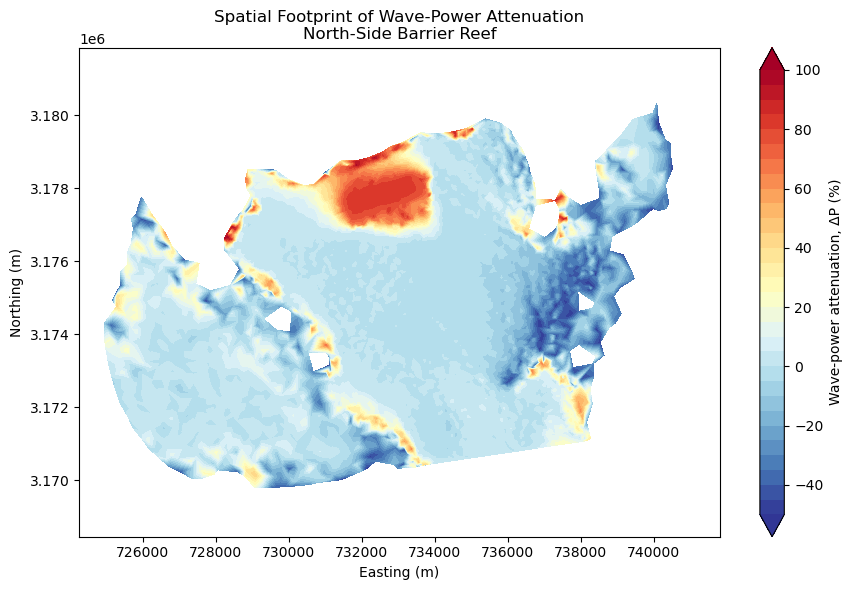

In [7]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey_with_reef_barrier_reef_Pattern.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"

target_time = np.datetime64("2017-08-26T02:30:00")

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# Reference grid: no-reef mesh
geom_ref = p_no_reef_all.geometry
xy_ref = geom_ref.element_coordinates[:, :2]

# Interpolate reef result to no-reef mesh
elem_ids, weights = p_reef_all.geometry.get_2d_interpolant(
    xy_ref,
    n_nearest=3,
    extrapolate=False
)

def interp_reef_to_ref(da_reef_t):
    return da_reef_t.geometry.interp2d(
        da_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP at target time
# =========================
time_index = np.argmin(np.abs(ds_no_reef.time.values - target_time))
selected_time = ds_no_reef.time.values[time_index]

p_no = p_no_reef_all.isel(time=time_index).to_numpy().flatten()
p_rf = interp_reef_to_ref(p_reef_all.isel(time=time_index))

# Avoid division by zero
p_no_safe = np.where(p_no > 1e-6, p_no, np.nan)

# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Smooth spatial footprint plot
# =========================
x = xy_ref[:, 0]
y = xy_ref[:, 1]
z = delta_p.copy()

# Mask invalid values
valid = np.isfinite(z)

# Optional: remove extreme/noisy values
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

# Create triangulation
triang = tri.Triangulation(x_valid, y_valid)

# Mask large triangles to avoid interpolation over land/gaps
triangles = triang.triangles

xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])

# Adjust this threshold if needed
# Smaller value = less interpolation across land/gaps
triang.set_mask(max_edge > 600)

# Plot smooth filled spatial footprint only
plt.figure(figsize=(9, 6))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

cbar = plt.colorbar(cf)
cbar.set_label("Wave-power attenuation, ΔP (%)")

plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.title("Spatial Footprint of Wave-Power Attenuation\nNorth-Side Barrier Reef")

plt.axis("equal")
plt.tight_layout()
plt.show()

Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): -3.503916229228023
Max ΔP (%): 83.45283017743222
Min ΔP (%): -1573.8273818963637


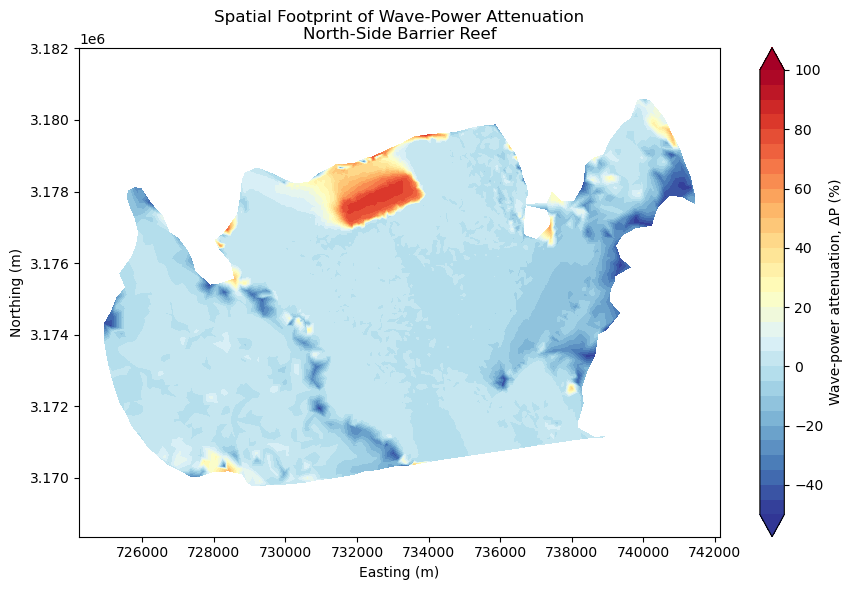

In [10]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Northside_barrier_reef_v1.sw - Result Files\Northside_barrier_reef_v1.dfsu"

dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"

target_time = np.datetime64("2017-08-26T02:30:00")

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# Reference grid: no-reef mesh
geom_ref = p_no_reef_all.geometry
xy_ref = geom_ref.element_coordinates[:, :2]

# Interpolate reef result to no-reef mesh
elem_ids, weights = p_reef_all.geometry.get_2d_interpolant(
    xy_ref,
    n_nearest=3,
    extrapolate=False
)

def interp_reef_to_ref(da_reef_t):
    return da_reef_t.geometry.interp2d(
        da_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP at target time
# =========================
time_index = np.argmin(np.abs(ds_no_reef.time.values - target_time))
selected_time = ds_no_reef.time.values[time_index]

p_no = p_no_reef_all.isel(time=time_index).to_numpy().flatten()
p_rf = interp_reef_to_ref(p_reef_all.isel(time=time_index))

# Avoid division by zero
p_no_safe = np.where(p_no > 1e-6, p_no, np.nan)

# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Smooth spatial footprint plot
# =========================
x = xy_ref[:, 0]
y = xy_ref[:, 1]
z = delta_p.copy()

# Mask invalid values
valid = np.isfinite(z)

# Optional: remove extreme/noisy values
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

# Create triangulation
triang = tri.Triangulation(x_valid, y_valid)

# Mask large triangles to avoid interpolation over land/gaps
triangles = triang.triangles

xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])

# Adjust this threshold if needed
# Smaller value = less interpolation across land/gaps
triang.set_mask(max_edge > 600)

# Plot smooth filled spatial footprint only
plt.figure(figsize=(9, 6))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

cbar = plt.colorbar(cf)
cbar.set_label("Wave-power attenuation, ΔP (%)")

plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.title("Spatial Footprint of Wave-Power Attenuation\nNorth-Side Barrier Reef")

plt.axis("equal")
plt.tight_layout()
plt.show()

Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): -4.928950542410028
Max ΔP (%): 88.4627417850795
Min ΔP (%): -12337.147317741239


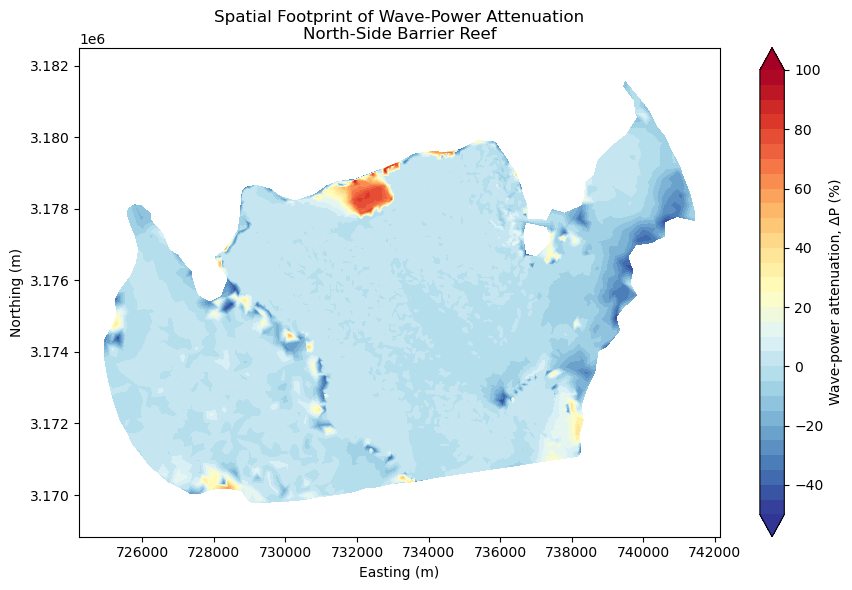

In [11]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Northside_barrier_reef_v2.sw - Result Files\Northside_barrier_reef_v2.dfsu"

dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"

target_time = np.datetime64("2017-08-26T02:30:00")

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# Reference grid: no-reef mesh
geom_ref = p_no_reef_all.geometry
xy_ref = geom_ref.element_coordinates[:, :2]

# Interpolate reef result to no-reef mesh
elem_ids, weights = p_reef_all.geometry.get_2d_interpolant(
    xy_ref,
    n_nearest=3,
    extrapolate=False
)

def interp_reef_to_ref(da_reef_t):
    return da_reef_t.geometry.interp2d(
        da_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP at target time
# =========================
time_index = np.argmin(np.abs(ds_no_reef.time.values - target_time))
selected_time = ds_no_reef.time.values[time_index]

p_no = p_no_reef_all.isel(time=time_index).to_numpy().flatten()
p_rf = interp_reef_to_ref(p_reef_all.isel(time=time_index))

# Avoid division by zero
p_no_safe = np.where(p_no > 1e-6, p_no, np.nan)

# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Smooth spatial footprint plot
# =========================
x = xy_ref[:, 0]
y = xy_ref[:, 1]
z = delta_p.copy()

# Mask invalid values
valid = np.isfinite(z)

# Optional: remove extreme/noisy values
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

# Create triangulation
triang = tri.Triangulation(x_valid, y_valid)

# Mask large triangles to avoid interpolation over land/gaps
triangles = triang.triangles

xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])

# Adjust this threshold if needed
# Smaller value = less interpolation across land/gaps
triang.set_mask(max_edge > 600)

# Plot smooth filled spatial footprint only
plt.figure(figsize=(9, 6))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

cbar = plt.colorbar(cf)
cbar.set_label("Wave-power attenuation, ΔP (%)")

plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.title("Spatial Footprint of Wave-Power Attenuation\nNorth-Side Barrier Reef")

plt.axis("equal")
plt.tight_layout()
plt.show()

Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): -3.571895396781399
Max ΔP (%): 86.82771727176383
Min ΔP (%): -3156.6800220283694


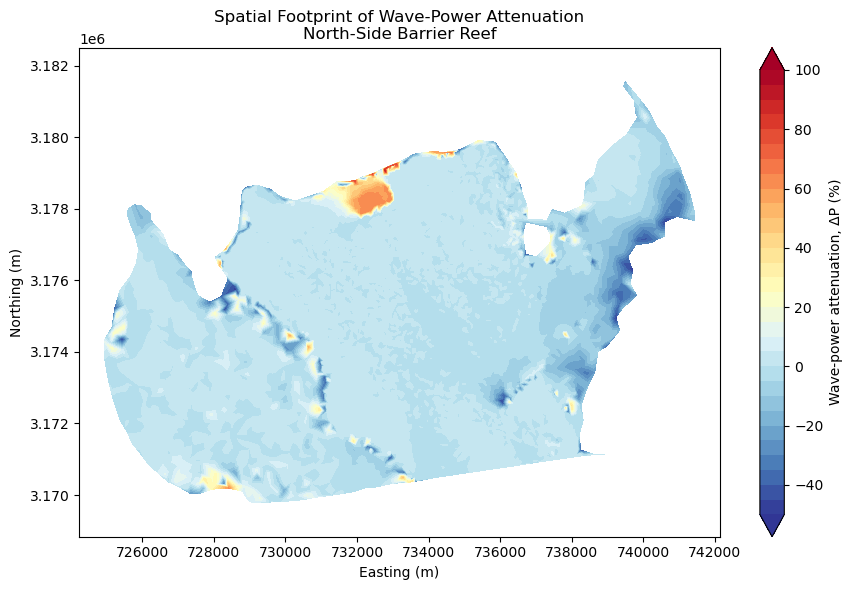

In [15]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Northside_barrier_reef_1.5m_v3.sw - Result Files\Northside_barrier_reef_1.5m_v3.dfsu"

dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"

target_time = np.datetime64("2017-08-26T02:30:00")

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# Reference grid: no-reef mesh
geom_ref = p_no_reef_all.geometry
xy_ref = geom_ref.element_coordinates[:, :2]

# Interpolate reef result to no-reef mesh
elem_ids, weights = p_reef_all.geometry.get_2d_interpolant(
    xy_ref,
    n_nearest=3,
    extrapolate=False
)

def interp_reef_to_ref(da_reef_t):
    return da_reef_t.geometry.interp2d(
        da_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP at target time
# =========================
time_index = np.argmin(np.abs(ds_no_reef.time.values - target_time))
selected_time = ds_no_reef.time.values[time_index]

p_no = p_no_reef_all.isel(time=time_index).to_numpy().flatten()
p_rf = interp_reef_to_ref(p_reef_all.isel(time=time_index))

# Avoid division by zero
p_no_safe = np.where(p_no > 1e-6, p_no, np.nan)

# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Smooth spatial footprint plot
# =========================
x = xy_ref[:, 0]
y = xy_ref[:, 1]
z = delta_p.copy()

# Mask invalid values
valid = np.isfinite(z)

# Optional: remove extreme/noisy values
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

# Create triangulation
triang = tri.Triangulation(x_valid, y_valid)

# Mask large triangles to avoid interpolation over land/gaps
triangles = triang.triangles

xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])

# Adjust this threshold if needed
# Smaller value = less interpolation across land/gaps
triang.set_mask(max_edge > 600)

# Plot smooth filled spatial footprint only
plt.figure(figsize=(9, 6))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

cbar = plt.colorbar(cf)
cbar.set_label("Wave-power attenuation, ΔP (%)")

plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.title("Spatial Footprint of Wave-Power Attenuation\nNorth-Side Barrier Reef")

plt.axis("equal")
plt.tight_layout()
plt.show()

Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): -3.571895396781399
Max ΔP (%): 86.82771727176383
Min ΔP (%): -3156.6800220283694


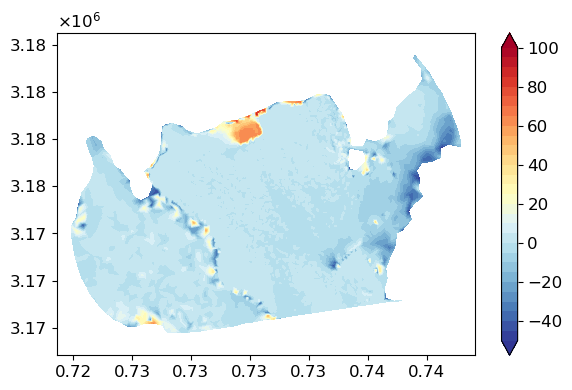

In [7]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.ticker import FormatStrFormatter

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Northside_barrier_reef_1.5m_v3.sw - Result Files\Northside_barrier_reef_1.5m_v3.dfsu"
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"

target_time = np.datetime64("2017-08-26T02:30:00")

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# Reference grid: no-reef mesh
geom_ref = p_no_reef_all.geometry
xy_ref = geom_ref.element_coordinates[:, :2]

# Interpolate reef result to no-reef mesh
elem_ids, weights = p_reef_all.geometry.get_2d_interpolant(
    xy_ref,
    n_nearest=3,
    extrapolate=False
)

def interp_reef_to_ref(da_reef_t):
    return da_reef_t.geometry.interp2d(
        da_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP at target time
# =========================
time_index = np.argmin(np.abs(ds_no_reef.time.values - target_time))
selected_time = ds_no_reef.time.values[time_index]

p_no = p_no_reef_all.isel(time=time_index).to_numpy().flatten()
p_rf = interp_reef_to_ref(p_reef_all.isel(time=time_index))

# Avoid division by zero
p_no_safe = np.where(p_no > 1e-6, p_no, np.nan)

# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Smooth spatial footprint plot
# =========================
x = xy_ref[:, 0]
y = xy_ref[:, 1]
z = delta_p.copy()

# Mask invalid values
valid = np.isfinite(z)

# Optional: remove extreme/noisy values
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

# Create triangulation
triang = tri.Triangulation(x_valid, y_valid)

# Mask large triangles to avoid interpolation over land/gaps
triangles = triang.triangles

xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])

# Adjust this threshold if needed
triang.set_mask(max_edge > 600)

# =========================
# Plot
# =========================

from matplotlib.ticker import FuncFormatter

tick_size = 12

plt.figure(figsize=(6, 4))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

# -------------------------
# Colorbar
# -------------------------
cbar = plt.colorbar(cf)
cbar.ax.tick_params(labelsize=tick_size)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
cbar.update_ticks()

# -------------------------
# Axes formatting
# -------------------------
ax = plt.gca()

# Tick label size
ax.tick_params(axis='both', labelsize=tick_size)

# Scientific notation with 2 decimals
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.2f}'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y/1e6:.2f}'))

# Display scientific multiplier (×10^6)
ax.text(
    0.0, 1.01,
    r'$\times10^{6}$',
    transform=ax.transAxes,
    fontsize=tick_size,
    ha='left',
    va='bottom'
)

# plt.xlabel("Easting (m)")
# plt.ylabel("Northing (m)")
# plt.title("Spatial Footprint of Wave-Power Attenuation\nEast-Side Barrier Reef")

plt.axis("equal")
plt.tight_layout()
plt.show()

Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): 0.5861884841077595
Max ΔP (%): 85.348333632517
Min ΔP (%): -2928.5648849186355


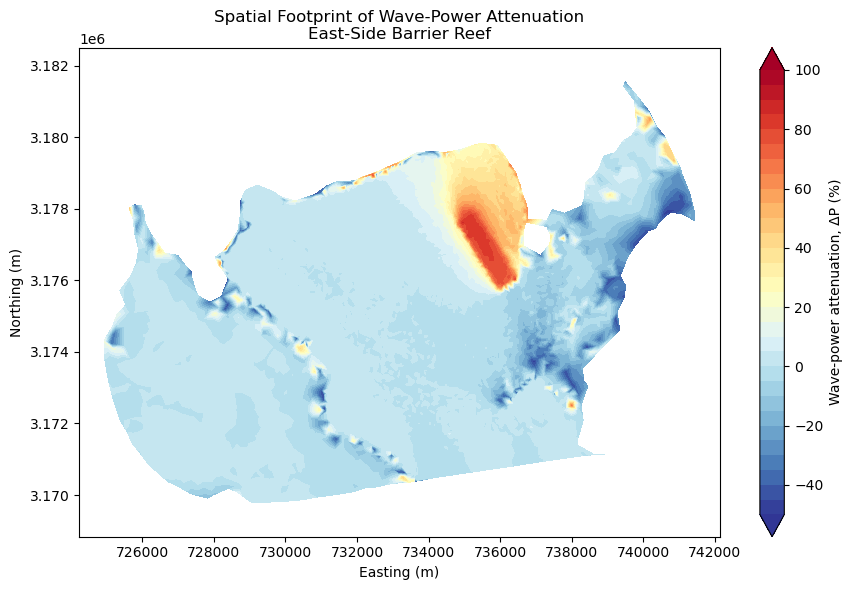

In [8]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef.sw - Result Files\east_side_reef.dfsu"
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"

target_time = np.datetime64("2017-08-26T02:30:00")

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# Reference grid: no-reef mesh
geom_ref = p_no_reef_all.geometry
xy_ref = geom_ref.element_coordinates[:, :2]

# Interpolate reef result to no-reef mesh
elem_ids, weights = p_reef_all.geometry.get_2d_interpolant(
    xy_ref,
    n_nearest=3,
    extrapolate=False
)

def interp_reef_to_ref(da_reef_t):
    return da_reef_t.geometry.interp2d(
        da_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP at target time
# =========================
time_index = np.argmin(np.abs(ds_no_reef.time.values - target_time))
selected_time = ds_no_reef.time.values[time_index]

p_no = p_no_reef_all.isel(time=time_index).to_numpy().flatten()
p_rf = interp_reef_to_ref(p_reef_all.isel(time=time_index))

# Avoid division by zero
p_no_safe = np.where(p_no > 1e-6, p_no, np.nan)

# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Smooth spatial footprint plot
# =========================
x = xy_ref[:, 0]
y = xy_ref[:, 1]
z = delta_p.copy()

# Mask invalid values
valid = np.isfinite(z)

# Optional: remove extreme/noisy values
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

# Create triangulation
triang = tri.Triangulation(x_valid, y_valid)

# Mask large triangles to avoid interpolation over land/gaps
triangles = triang.triangles

xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])

# Adjust this threshold if needed
# Smaller value = less interpolation across land/gaps
triang.set_mask(max_edge > 600)

# Plot smooth filled spatial footprint only
plt.figure(figsize=(9, 6))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

cbar = plt.colorbar(cf)
cbar.set_label("Wave-power attenuation, ΔP (%)")

plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.title("Spatial Footprint of Wave-Power Attenuation\nEast-Side Barrier Reef")

plt.axis("equal")
plt.tight_layout()
plt.show()

Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): -0.7935126575575434
Max ΔP (%): 87.16188738195063
Min ΔP (%): -2266.3667106215803


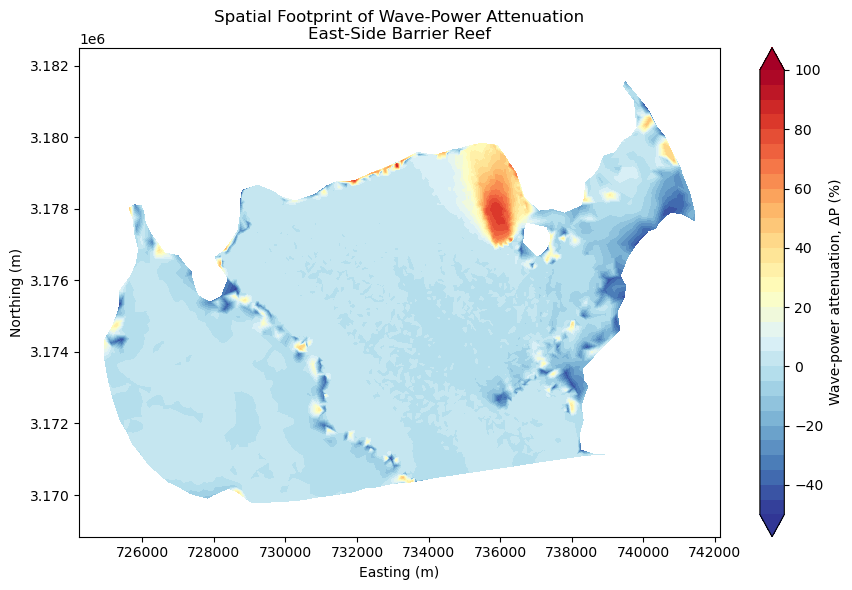

In [13]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef_v1.sw - Result Files\east_side_reef_v1.dfsu"
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"

target_time = np.datetime64("2017-08-26T02:30:00")

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# Reference grid: no-reef mesh
geom_ref = p_no_reef_all.geometry
xy_ref = geom_ref.element_coordinates[:, :2]

# Interpolate reef result to no-reef mesh
elem_ids, weights = p_reef_all.geometry.get_2d_interpolant(
    xy_ref,
    n_nearest=3,
    extrapolate=False
)

def interp_reef_to_ref(da_reef_t):
    return da_reef_t.geometry.interp2d(
        da_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP at target time
# =========================
time_index = np.argmin(np.abs(ds_no_reef.time.values - target_time))
selected_time = ds_no_reef.time.values[time_index]

p_no = p_no_reef_all.isel(time=time_index).to_numpy().flatten()
p_rf = interp_reef_to_ref(p_reef_all.isel(time=time_index))

# Avoid division by zero
p_no_safe = np.where(p_no > 1e-6, p_no, np.nan)

# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Smooth spatial footprint plot
# =========================
x = xy_ref[:, 0]
y = xy_ref[:, 1]
z = delta_p.copy()

# Mask invalid values
valid = np.isfinite(z)

# Optional: remove extreme/noisy values
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

# Create triangulation
triang = tri.Triangulation(x_valid, y_valid)

# Mask large triangles to avoid interpolation over land/gaps
triangles = triang.triangles

xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])

# Adjust this threshold if needed
# Smaller value = less interpolation across land/gaps
triang.set_mask(max_edge > 600)

# Plot smooth filled spatial footprint only
plt.figure(figsize=(9, 6))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

cbar = plt.colorbar(cf)
cbar.set_label("Wave-power attenuation, ΔP (%)")

plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.title("Spatial Footprint of Wave-Power Attenuation\nEast-Side Barrier Reef")

plt.axis("equal")
plt.tight_layout()
plt.show()

Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): -1.4147538514639333
Max ΔP (%): 87.15285591014181
Min ΔP (%): -2265.6026675119538


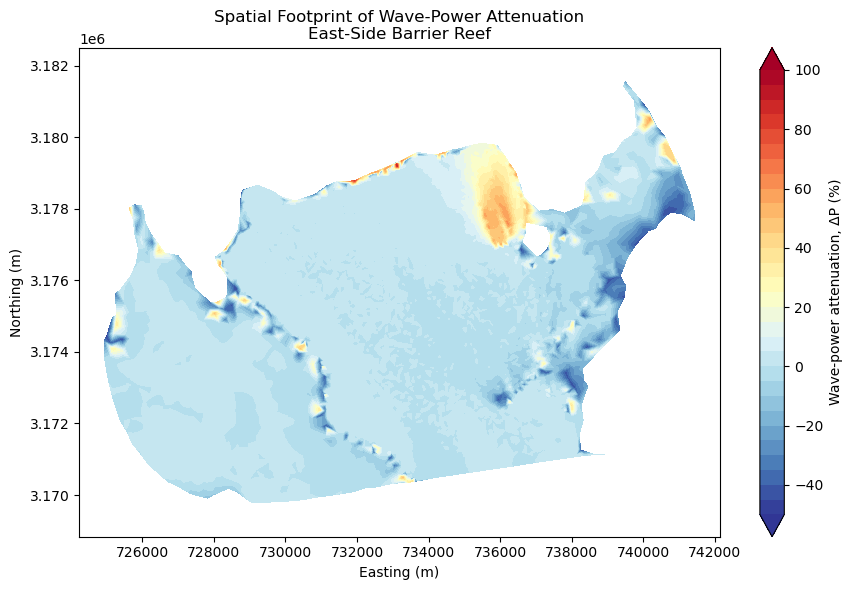

In [14]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef_1.5m_v2.sw - Result Files\east_side_reef_1.5m_v2.dfsu"
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"

target_time = np.datetime64("2017-08-26T02:30:00")

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# Reference grid: no-reef mesh
geom_ref = p_no_reef_all.geometry
xy_ref = geom_ref.element_coordinates[:, :2]

# Interpolate reef result to no-reef mesh
elem_ids, weights = p_reef_all.geometry.get_2d_interpolant(
    xy_ref,
    n_nearest=3,
    extrapolate=False
)

def interp_reef_to_ref(da_reef_t):
    return da_reef_t.geometry.interp2d(
        da_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP at target time
# =========================
time_index = np.argmin(np.abs(ds_no_reef.time.values - target_time))
selected_time = ds_no_reef.time.values[time_index]

p_no = p_no_reef_all.isel(time=time_index).to_numpy().flatten()
p_rf = interp_reef_to_ref(p_reef_all.isel(time=time_index))

# Avoid division by zero
p_no_safe = np.where(p_no > 1e-6, p_no, np.nan)

# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Smooth spatial footprint plot
# =========================
x = xy_ref[:, 0]
y = xy_ref[:, 1]
z = delta_p.copy()

# Mask invalid values
valid = np.isfinite(z)

# Optional: remove extreme/noisy values
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

# Create triangulation
triang = tri.Triangulation(x_valid, y_valid)

# Mask large triangles to avoid interpolation over land/gaps
triangles = triang.triangles

xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])

# Adjust this threshold if needed
# Smaller value = less interpolation across land/gaps
triang.set_mask(max_edge > 600)

# Plot smooth filled spatial footprint only
plt.figure(figsize=(9, 6))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

cbar = plt.colorbar(cf)
cbar.set_label("Wave-power attenuation, ΔP (%)")

plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.title("Spatial Footprint of Wave-Power Attenuation\nEast-Side Barrier Reef")

plt.axis("equal")
plt.tight_layout()
plt.show()

Selected timestep: 2017-08-26T02:30:00.000000000
Mean ΔP (%): -1.4147538514639333
Max ΔP (%): 87.15285591014181
Min ΔP (%): -2265.6026675119538


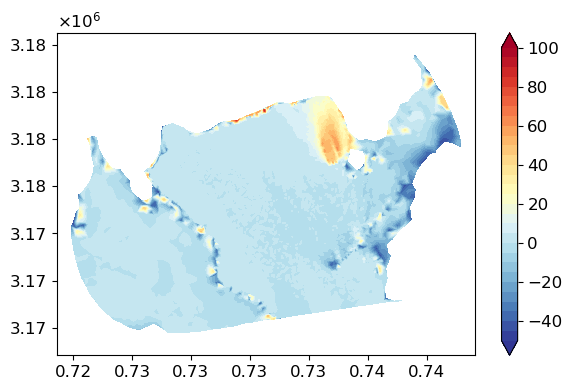

In [6]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.ticker import FormatStrFormatter

# =========================
# File paths
# =========================
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef_1.5m_v2.sw - Result Files\east_side_reef_1.5m_v2.dfsu"
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

item_name = "Wave power, p"

target_time = np.datetime64("2017-08-26T02:30:00")

# =========================
# Open and read files
# =========================
dfs_reef = mikeio.open(dfsu_reef)
dfs_no_reef = mikeio.open(dfsu_no_reef)

ds_reef = dfs_reef.read(items=[item_name])
ds_no_reef = dfs_no_reef.read(items=[item_name])

p_reef_all = ds_reef[item_name]
p_no_reef_all = ds_no_reef[item_name]

# Reference grid: no-reef mesh
geom_ref = p_no_reef_all.geometry
xy_ref = geom_ref.element_coordinates[:, :2]

# Interpolate reef result to no-reef mesh
elem_ids, weights = p_reef_all.geometry.get_2d_interpolant(
    xy_ref,
    n_nearest=3,
    extrapolate=False
)

def interp_reef_to_ref(da_reef_t):
    return da_reef_t.geometry.interp2d(
        da_reef_t,
        elem_ids,
        weights
    ).flatten()

# =========================
# Calculate ΔP at target time
# =========================
time_index = np.argmin(np.abs(ds_no_reef.time.values - target_time))
selected_time = ds_no_reef.time.values[time_index]

p_no = p_no_reef_all.isel(time=time_index).to_numpy().flatten()
p_rf = interp_reef_to_ref(p_reef_all.isel(time=time_index))

# Avoid division by zero
p_no_safe = np.where(p_no > 1e-6, p_no, np.nan)

# ΔP = (P_no_reef - P_reef) / P_no_reef * 100
delta_p = ((p_no_safe - p_rf) / p_no_safe) * 100

print("Selected timestep:", selected_time)
print("Mean ΔP (%):", np.nanmean(delta_p))
print("Max ΔP (%):", np.nanmax(delta_p))
print("Min ΔP (%):", np.nanmin(delta_p))

# =========================
# Smooth spatial footprint plot
# =========================
x = xy_ref[:, 0]
y = xy_ref[:, 1]
z = delta_p.copy()

# Mask invalid values
valid = np.isfinite(z)

# Optional: remove extreme/noisy values
valid &= (z >= -50) & (z <= 100)

x_valid = x[valid]
y_valid = y[valid]
z_valid = z[valid]

# Create triangulation
triang = tri.Triangulation(x_valid, y_valid)

# Mask large triangles to avoid interpolation over land/gaps
triangles = triang.triangles

xtri = x_valid[triangles]
ytri = y_valid[triangles]

edge1 = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
edge2 = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
edge3 = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([edge1, edge2, edge3])

# Adjust this threshold if needed
triang.set_mask(max_edge > 600)

# =========================
# Plot
# =========================

from matplotlib.ticker import FuncFormatter

tick_size = 12

plt.figure(figsize=(6, 4))

levels = np.linspace(-50, 100, 31)

cf = plt.tricontourf(
    triang,
    z_valid,
    levels=levels,
    cmap="RdYlBu_r",
    extend="both"
)

# -------------------------
# Colorbar
# -------------------------
cbar = plt.colorbar(cf)
cbar.ax.tick_params(labelsize=tick_size)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
cbar.update_ticks()

# -------------------------
# Axes formatting
# -------------------------
ax = plt.gca()

# Tick label size
ax.tick_params(axis='both', labelsize=tick_size)

# Scientific notation with 2 decimals
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.2f}'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y/1e6:.2f}'))

# Display scientific multiplier (×10^6)
ax.text(
    0.0, 1.01,
    r'$\times10^{6}$',
    transform=ax.transAxes,
    fontsize=tick_size,
    ha='left',
    va='bottom'
)

# plt.xlabel("Easting (m)")
# plt.ylabel("Northing (m)")
# plt.title("Spatial Footprint of Wave-Power Attenuation\nEast-Side Barrier Reef")

plt.axis("equal")
plt.tight_layout()
plt.show()